In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [4]:
from google.colab import files
uploaded = files.upload()

Saving cardekho.csv to cardekho (1).csv


In [6]:
data = pd.read_csv("cardekho.csv")
data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


In [8]:
data.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000,7907.000000,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.418783,1458.625016,5.416719
std,4.044249,8.062534e+05,5.655055e+04,4.037145,503.916303,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.780000,1197.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


In [9]:
X = data[['year','km_driven','mileage(km/ltr/kg)','engine','max_power','seats']]

In [10]:
Y = data['selling_price']

In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [13]:
data = data.replace(' ', np.nan)

In [14]:
data['mileage(km/ltr/kg)'] = data['mileage(km/ltr/kg)'].astype(str).str.split().str[0]
data['mileage(km/ltr/kg)'] = pd.to_numeric(data['mileage(km/ltr/kg)'], errors='coerce')

In [15]:
data['engine'] = data['engine'].astype(str).str.split().str[0]
data['engine'] = pd.to_numeric(data['engine'], errors='coerce')

In [16]:
data['max_power'] = data['max_power'].astype(str).str.split().str[0]
data['max_power'] = pd.to_numeric(data['max_power'], errors='coerce')

In [17]:
data = data.dropna()

In [18]:
X = data[['year','km_driven','mileage(km/ltr/kg)','engine','max_power','seats']]
Y = data['selling_price']

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [21]:
Y_pred = model.predict(X_test)

print("Predicted Prices:")
print(Y_pred[:10])

Predicted Prices:
[ 419824.79689696  418273.5488043    45045.09126915  501314.68857926
  767355.09179316  873369.58745871  744879.46395583  565711.15878969
 -206494.60910788  510703.93852848]


In [22]:
results = pd.DataFrame({
    "Actual Price": Y_test,
    "Predicted Price": Y_pred
})

print(results.head(10))

      Actual Price  Predicted Price
3756        501000    419824.796897
5692        440000    418273.548804
3637        140000     45045.091269
7693        476999    501314.688579
3565        620000    767355.091793
5919        380000    873369.587459
3225        360000    744879.463956
5316        185000    565711.158790
4178        157000   -206494.609108
2545        600000    510703.938528


In [23]:
from sklearn.metrics import r2_score

score = r2_score(Y_test, Y_pred)

print("R2 Score:", score)

R2 Score: 0.6512744067090093


In [24]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: -79456990.97474405
Coefficients: [ 3.91318769e+04 -1.87784999e+00  1.03486652e+04  1.29855238e+02
  1.52436118e+04 -6.68323179e+04]


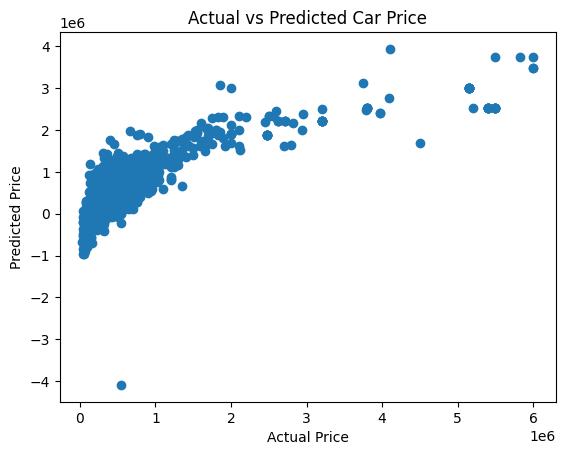

In [25]:
import matplotlib.pyplot as plt

plt.scatter(Y_test, Y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Price")

plt.show()